In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\kumar\Downloads\Country-data.csv")

In [3]:
df.head(5)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


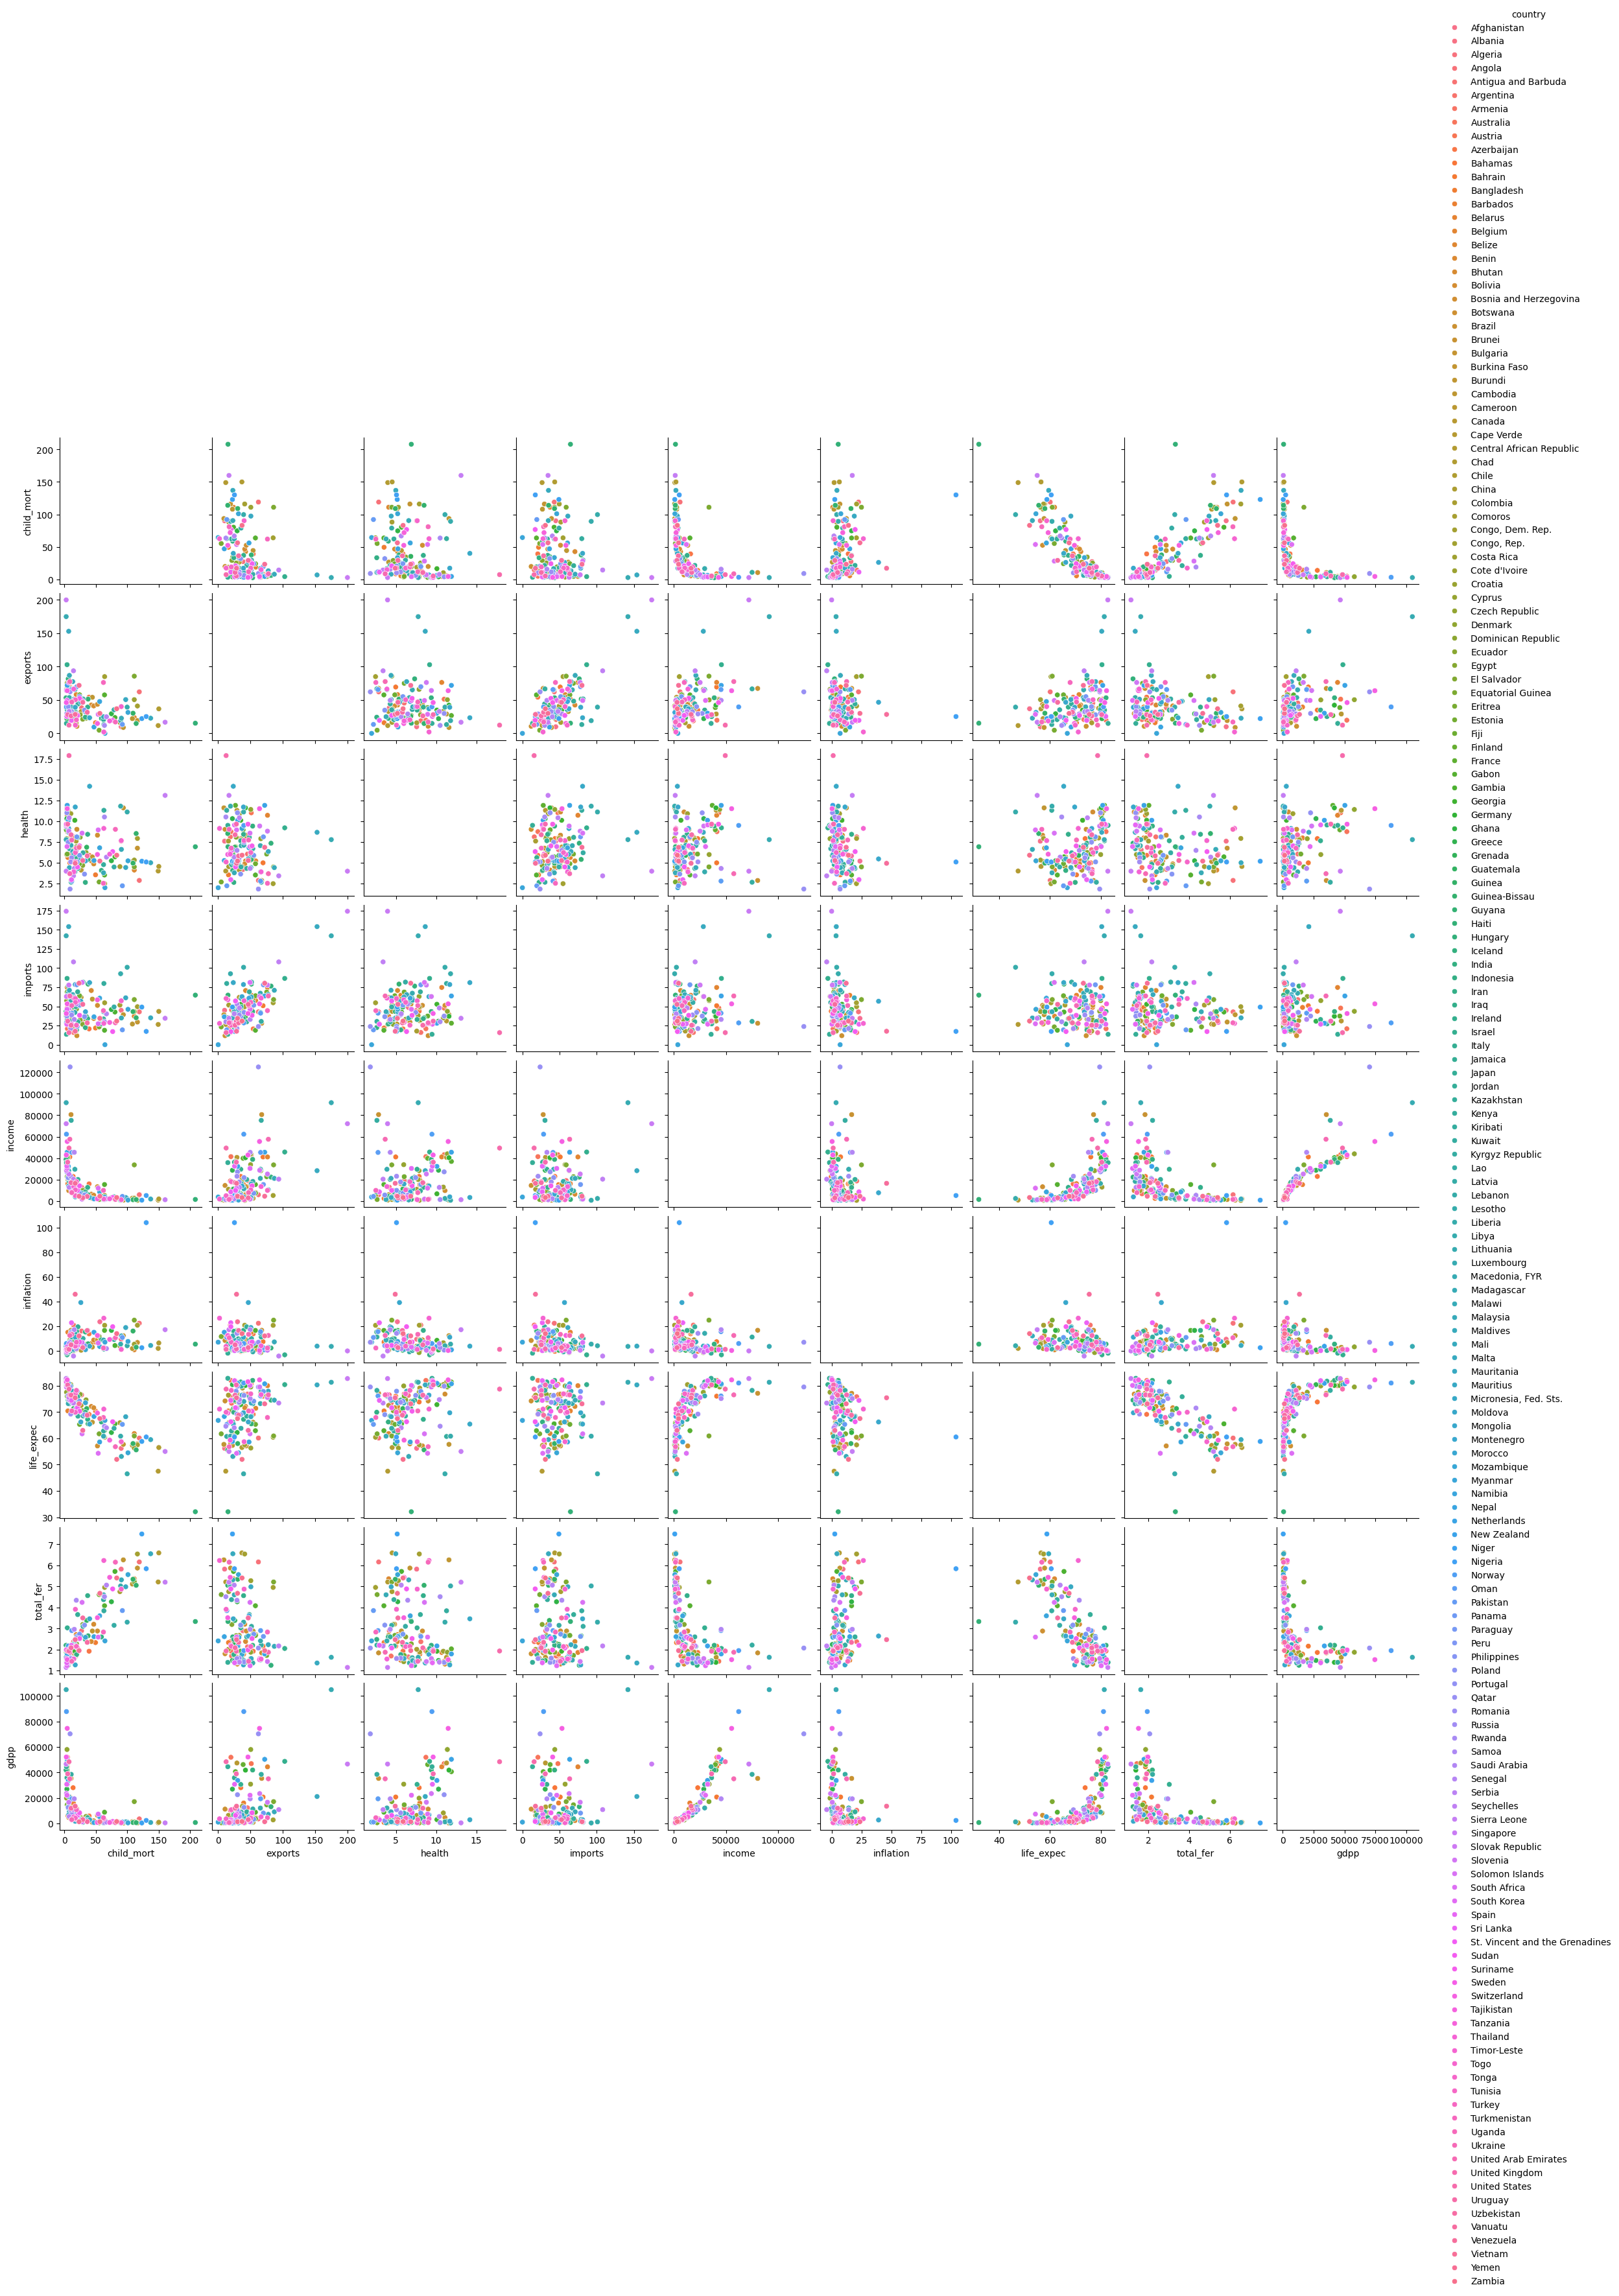

In [4]:
sns.pairplot(data=df,hue="country")
plt.show()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [6]:
d=df.copy()

In [7]:
d.drop(columns="country",inplace=True)

In [8]:
d

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


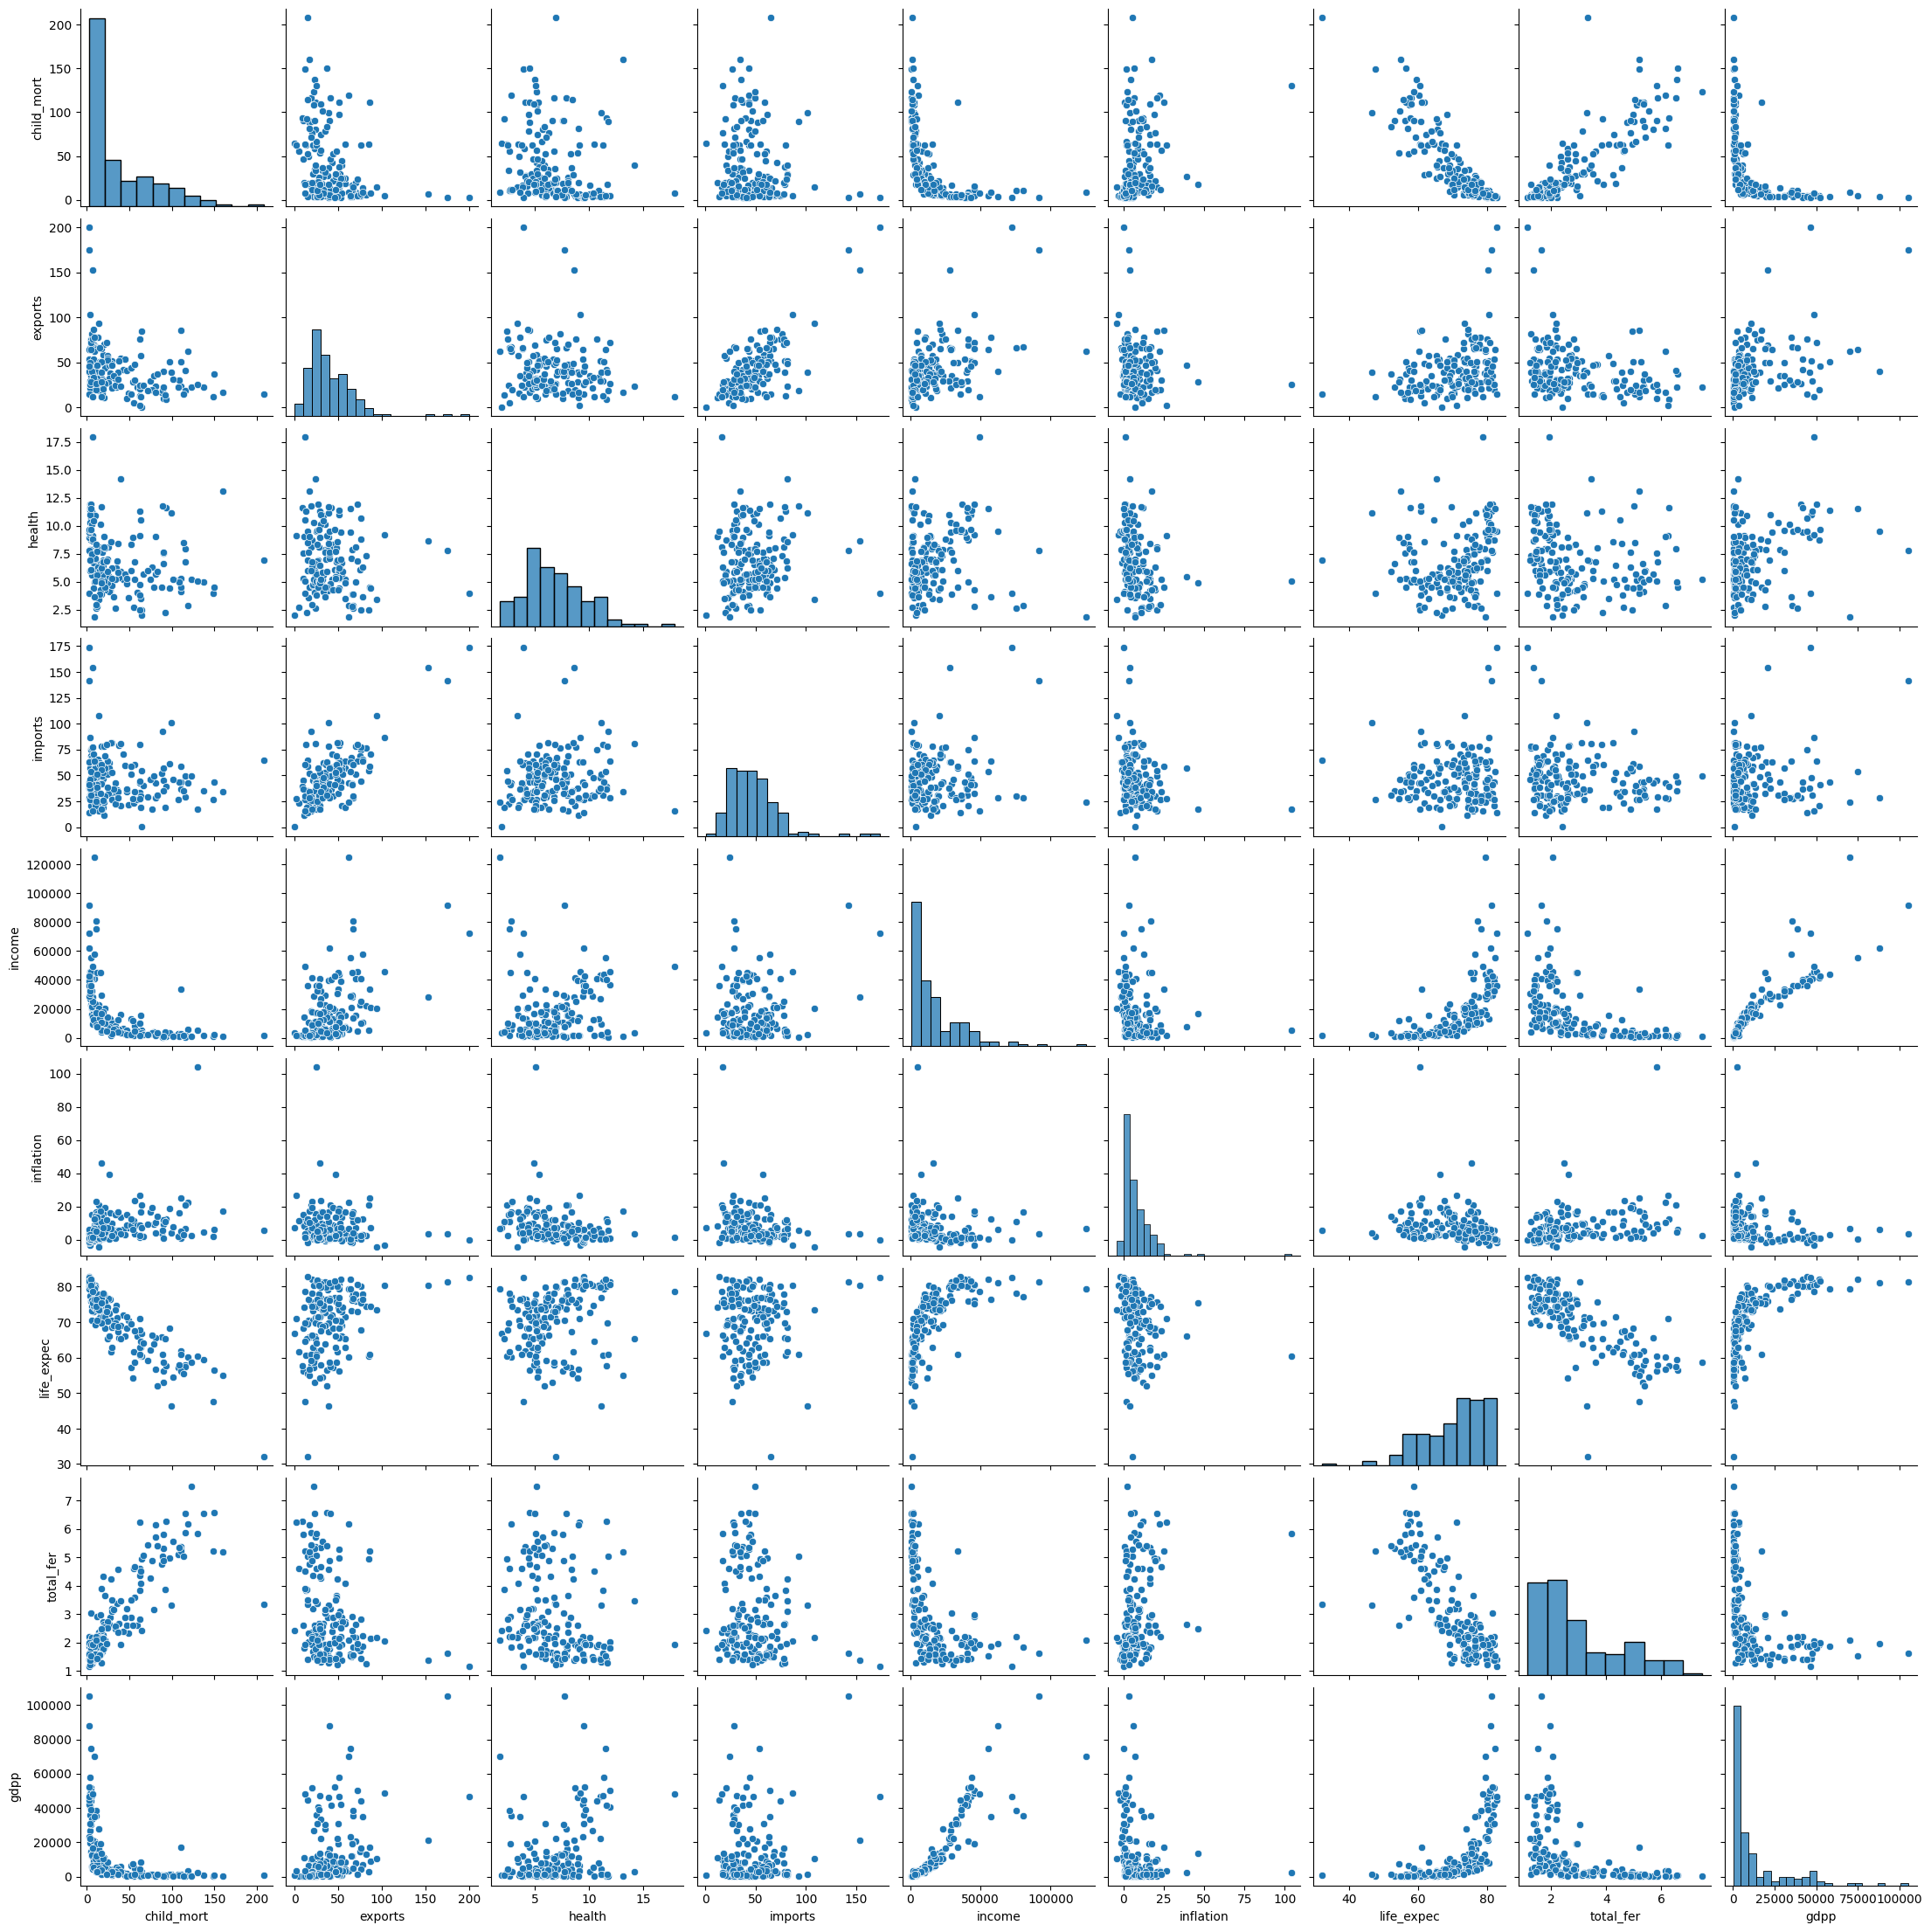

In [9]:
sns.pairplot(data=d)
plt.show()

# K Mean clustering


In [10]:
from sklearn.cluster import KMeans

In [11]:
wcss=[]
for i in range(2,100):
    km=KMeans(n_clusters=i,init='k-means++')
    km.fit(d)
    wcss.append(km.inertia_)

In [12]:
wcss

[36528387934.3221,
 21710210039.75414,
 14610713446.535131,
 11434204183.939798,
 7655725089.094505,
 5353767457.732321,
 4319251643.796237,
 3228565265.69808,
 2796486922.8341618,
 2440192616.1251717,
 1969473305.4716122,
 1547228017.275797,
 1521078429.7664557,
 1162639388.3840365,
 1145615543.3029578,
 980010322.8228372,
 863872847.8260678,
 787711274.0046973,
 770236969.6300048,
 664984578.9504987,
 682553965.6810815,
 557955099.7469226,
 490597917.4341277,
 489367453.24961793,
 454272636.8695253,
 422642336.9523119,
 392071059.41830015,
 339013475.21156645,
 341888237.7488799,
 330895510.78719205,
 281061097.02993083,
 284434859.7685271,
 241673123.9965503,
 237155301.11916357,
 223084954.52528742,
 217284187.0562907,
 209530594.48626843,
 198614040.06622794,
 176443288.1342396,
 154712925.40530565,
 155390618.9005099,
 137337318.11649603,
 130199177.6419962,
 121569777.32740785,
 119549756.47899108,
 112492298.83966239,
 99256074.28128883,
 100300632.73931576,
 89454232.27441919,

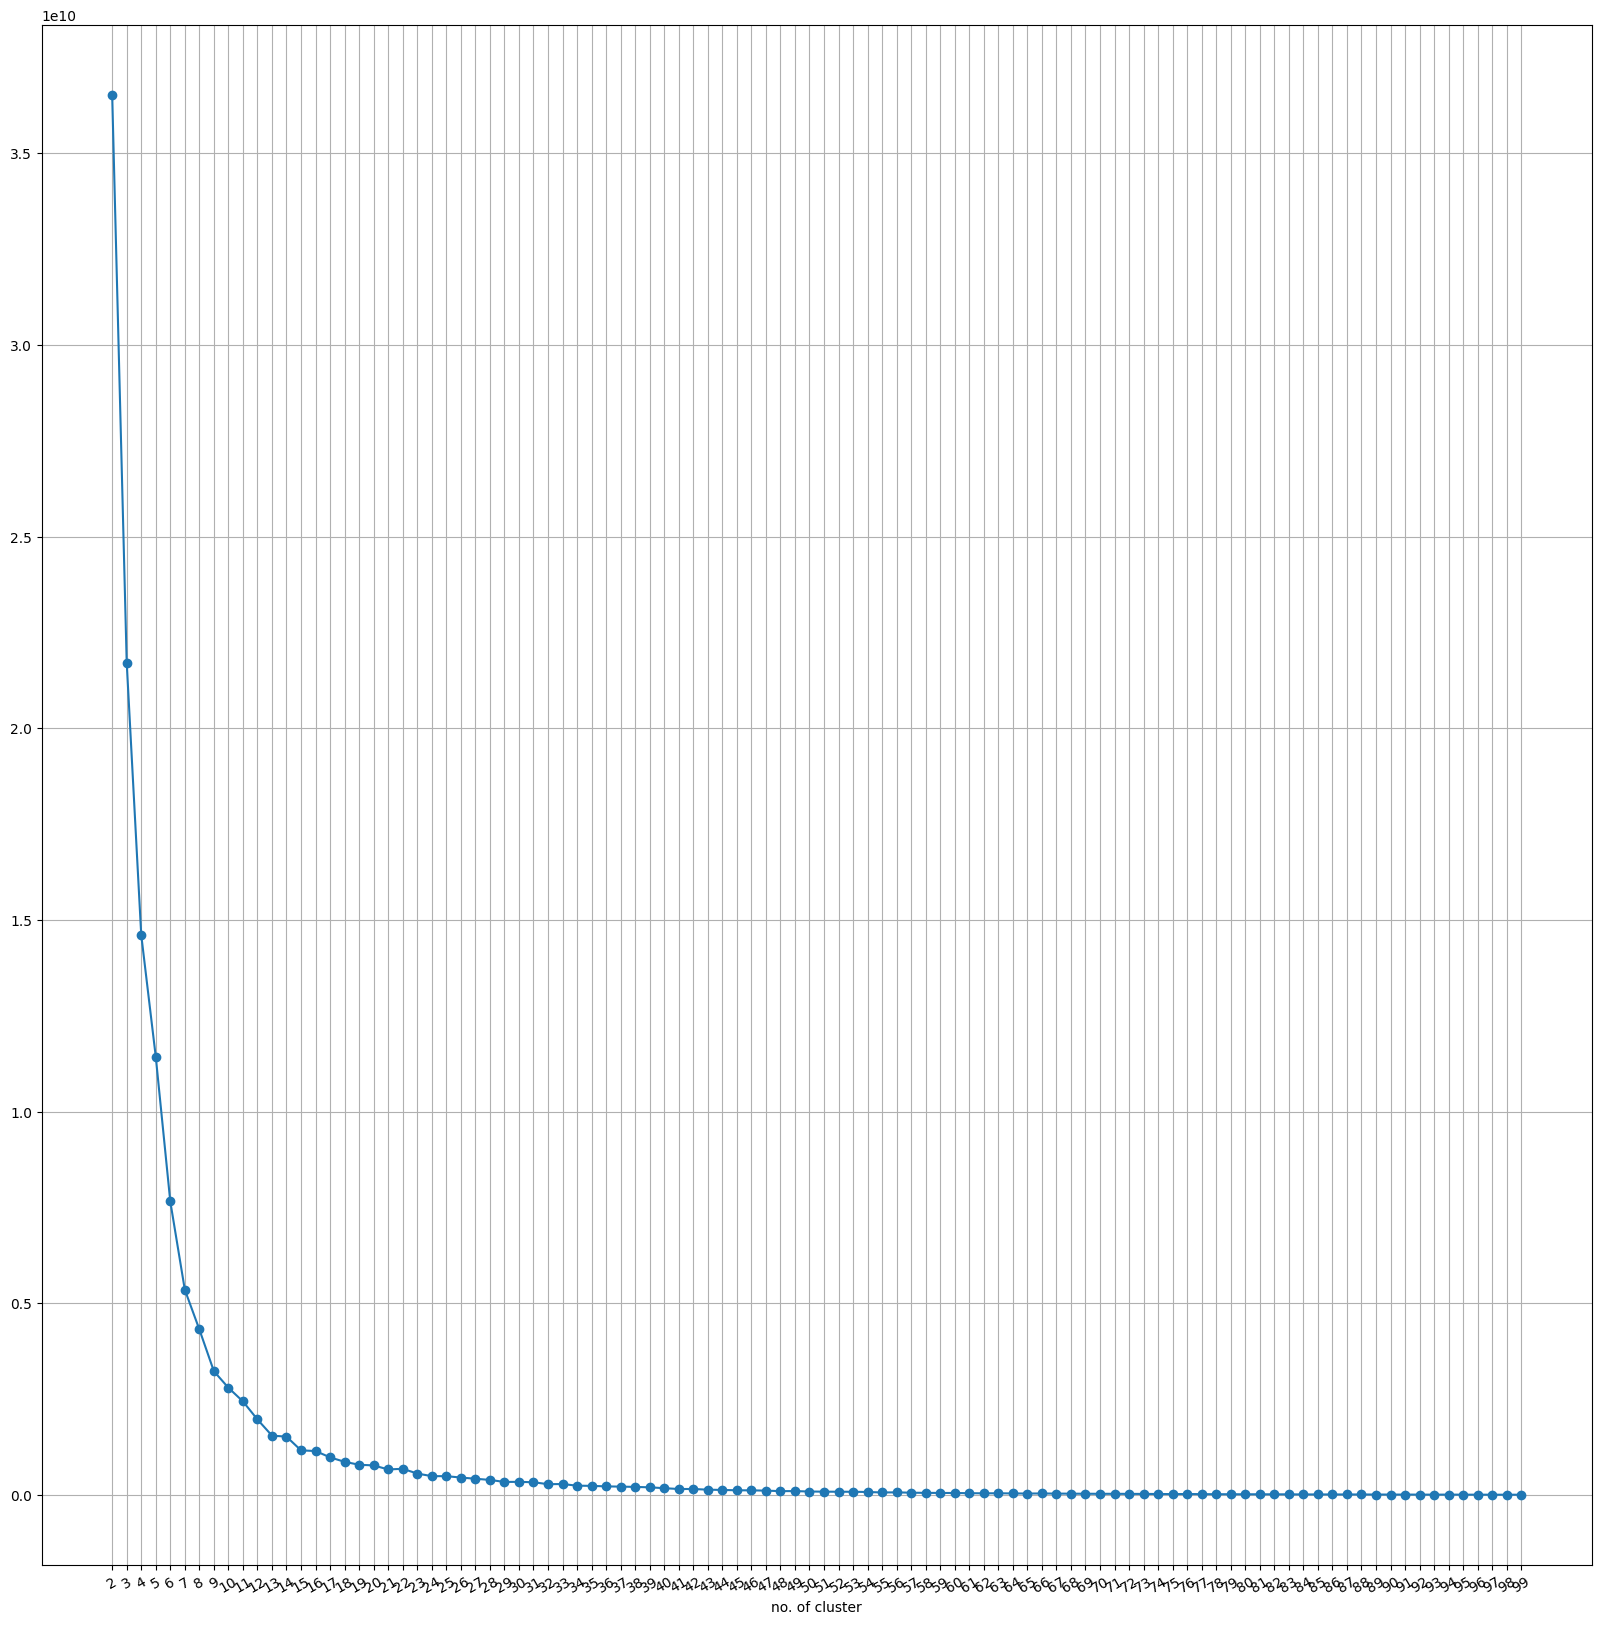

In [13]:
plt.figure(figsize=(20,20))
plt.plot([i for i in range(2,100)],wcss,marker="o")
plt.xlabel("no. of cluster")
plt.xticks([i for i in range(2,100)])
plt.xticks(rotation=30)
plt.grid()
plt.show()

In [14]:
km1=KMeans(n_clusters=10,init='k-means++')

In [15]:
d["predict"]=km1.fit_predict(d)

In [16]:
d

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,predict
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,5
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,0
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,7
...,...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,5
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,7
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,5
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,5


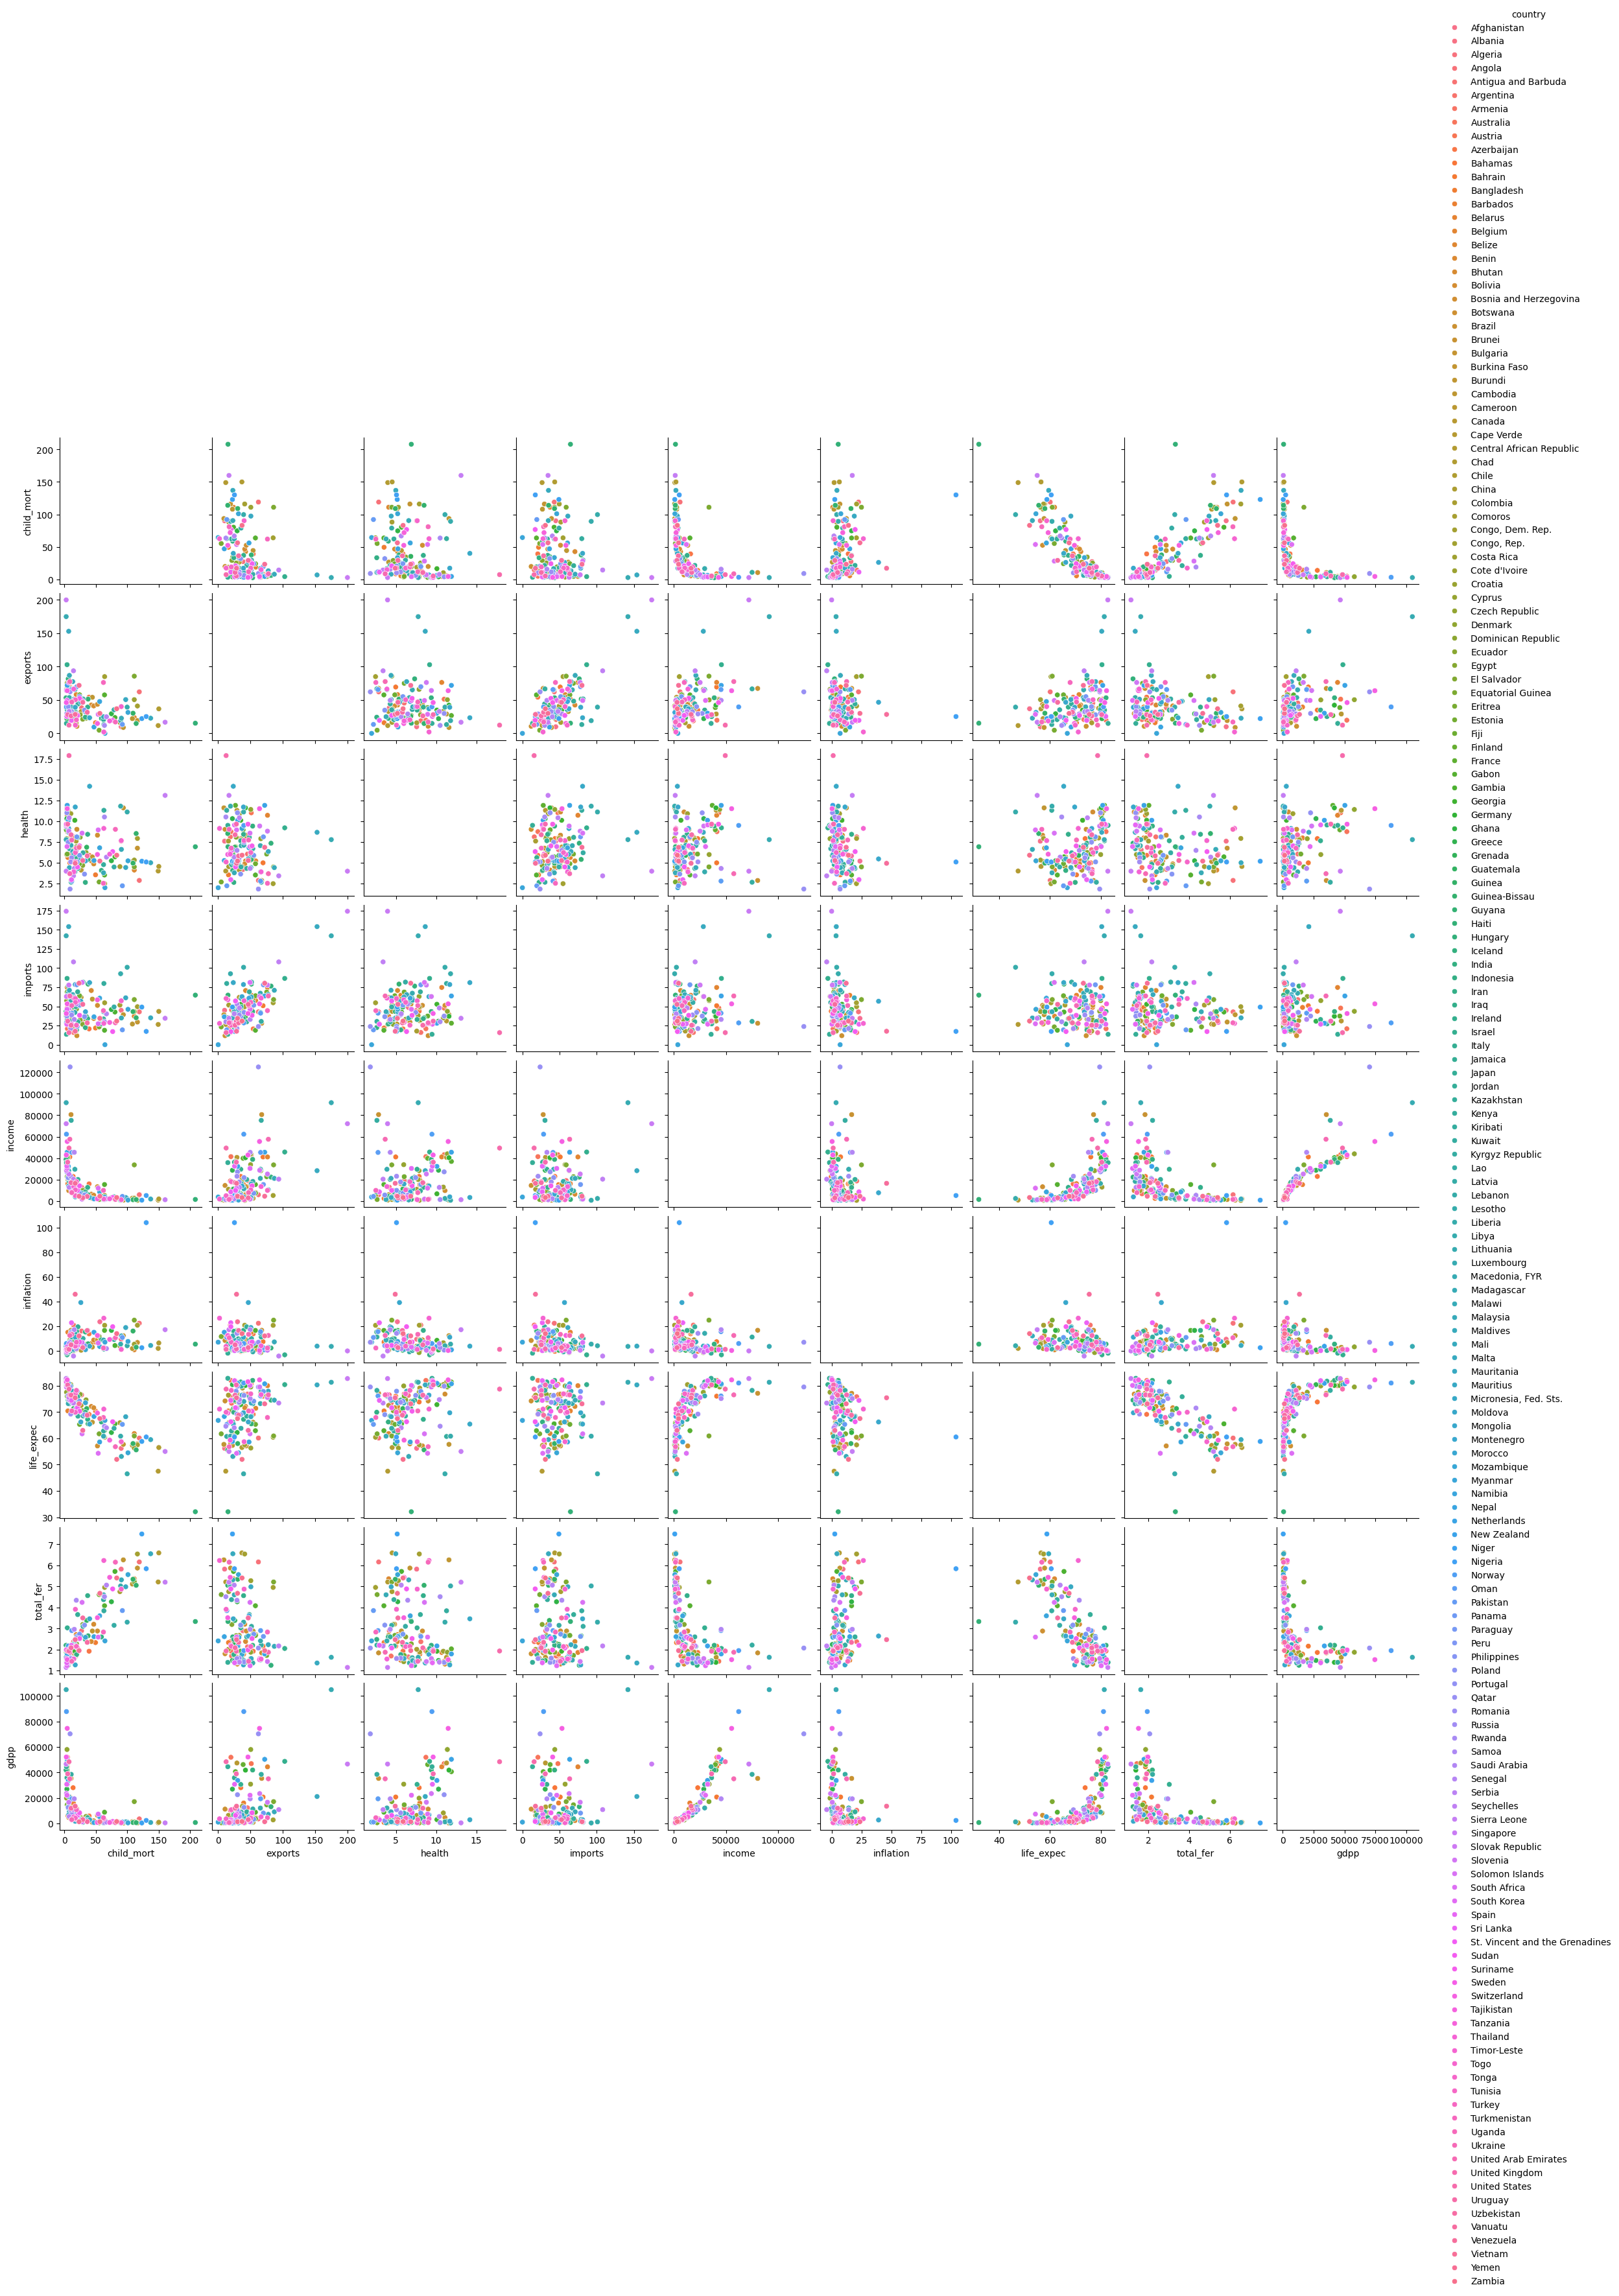

In [17]:
sns.pairplot(data=df,hue="country")
plt.show()

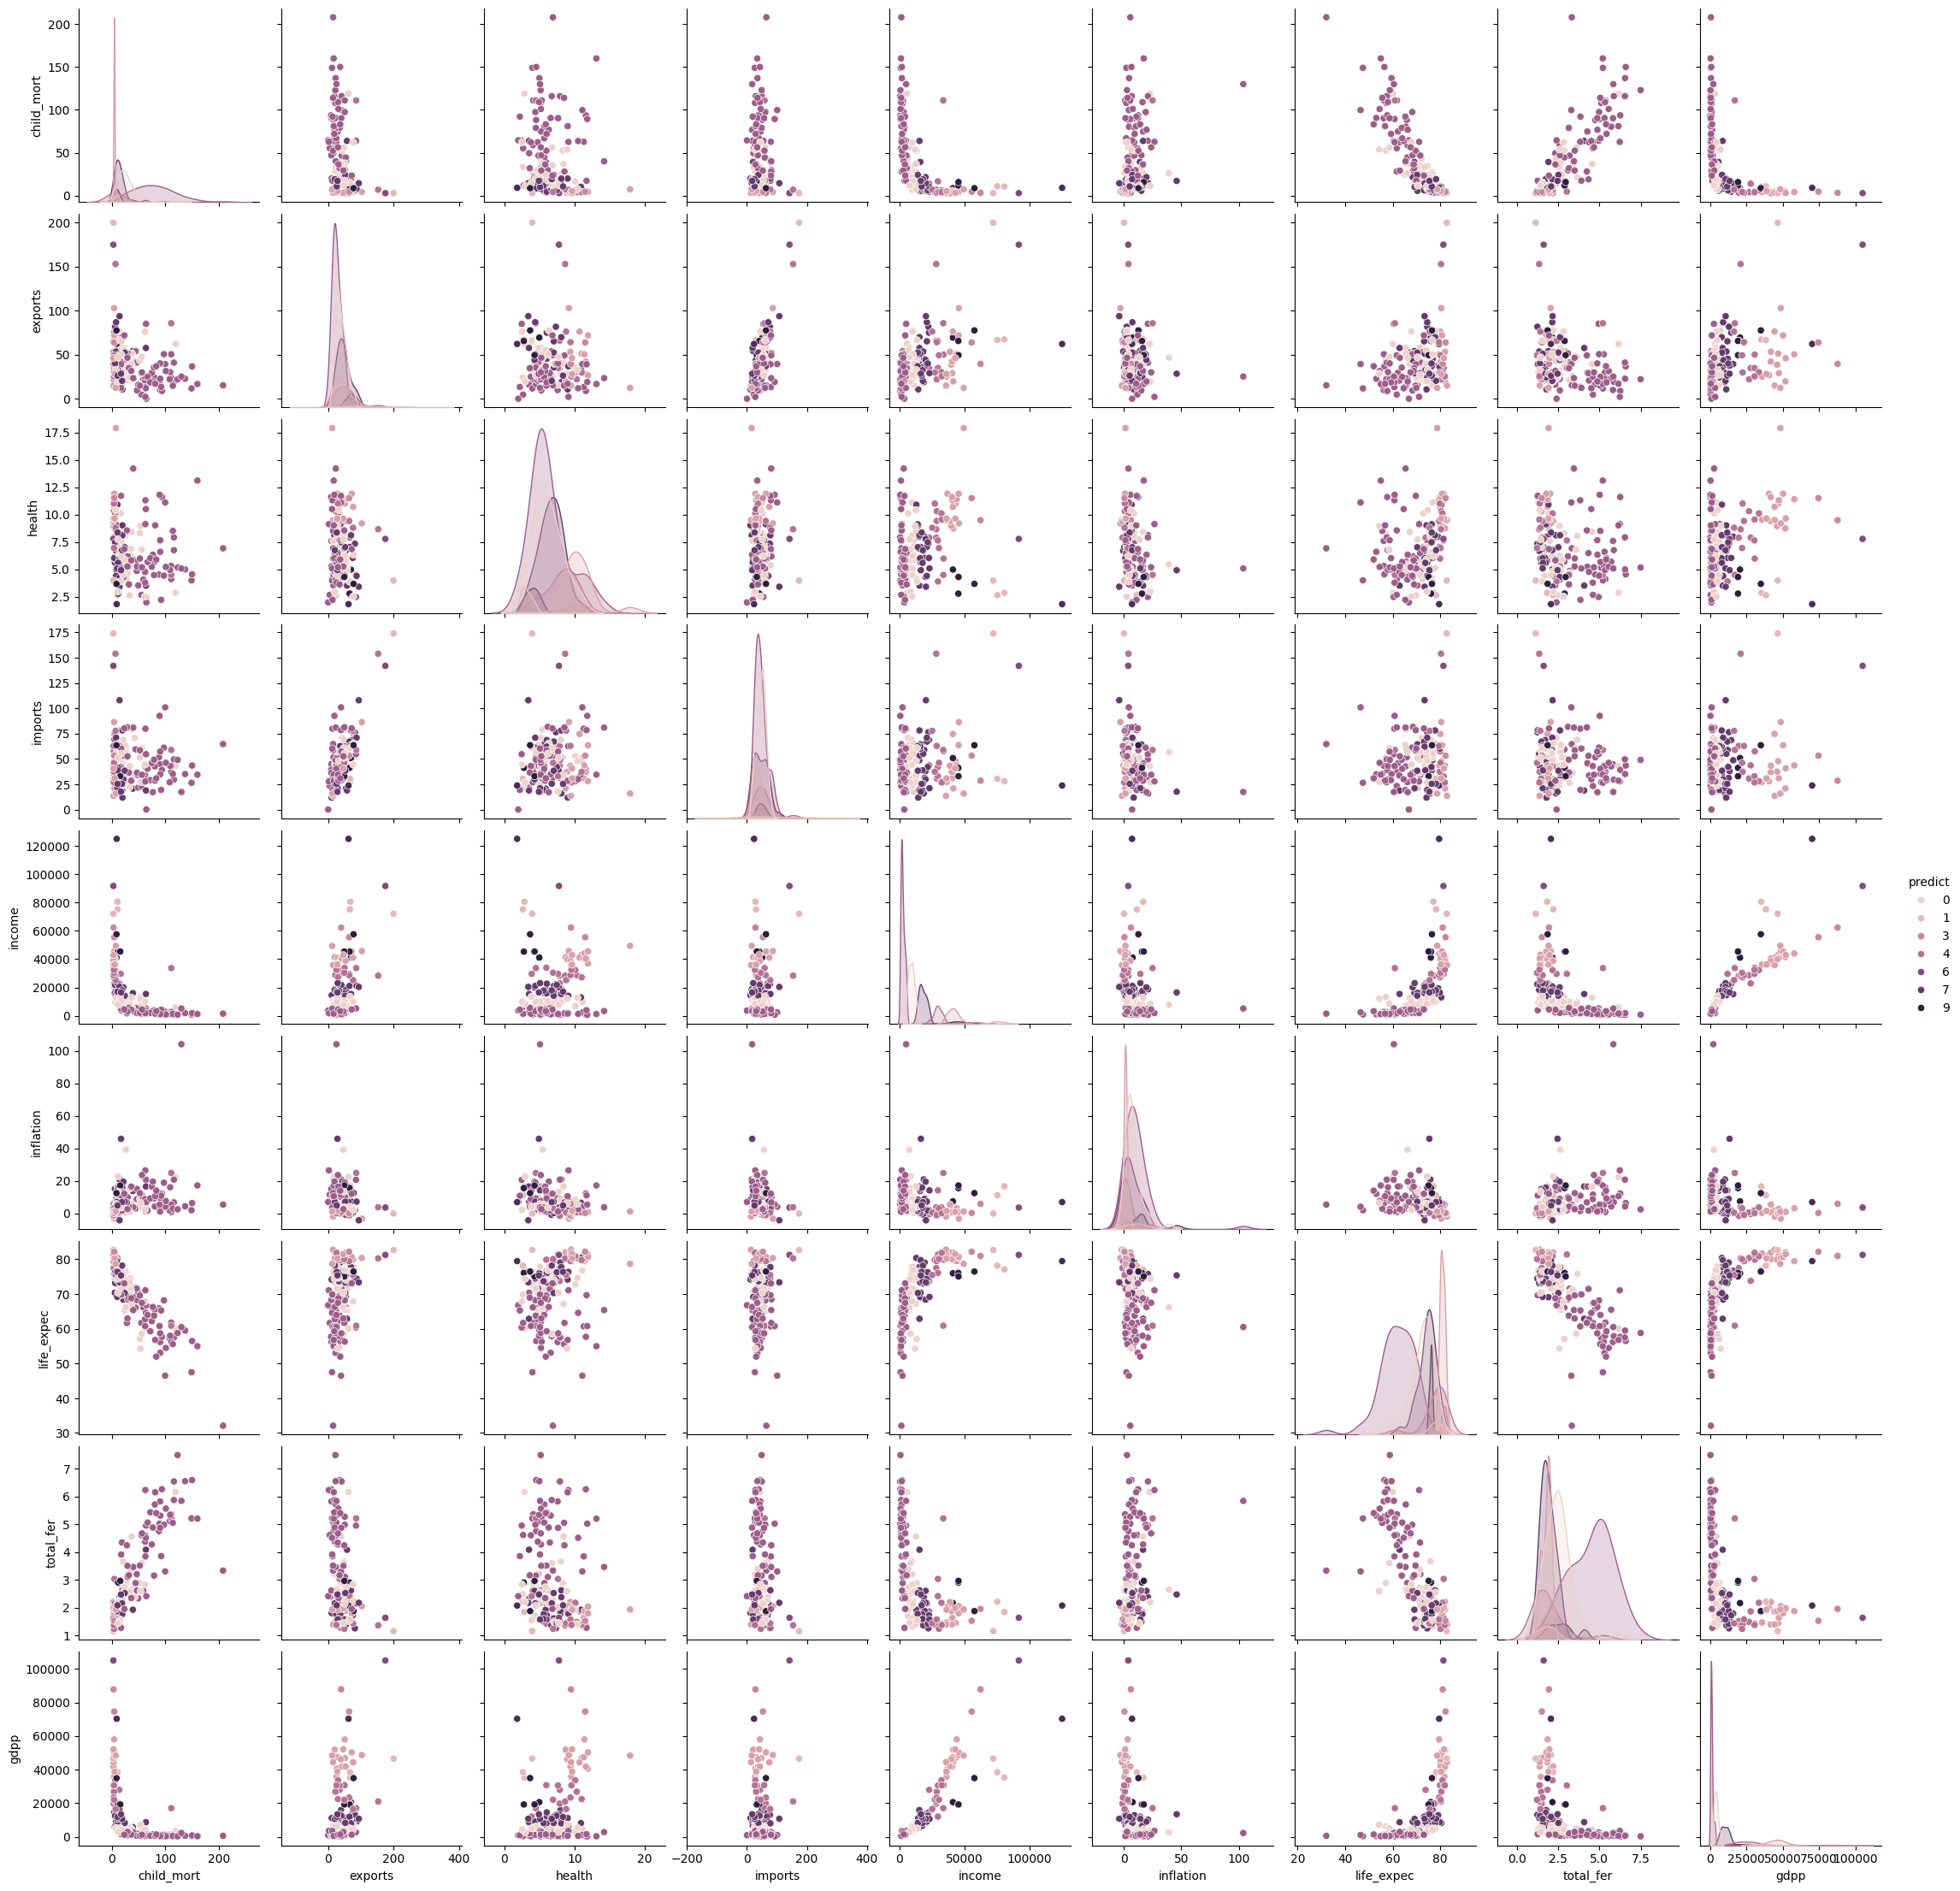

In [18]:
sns.pairplot(data=d,hue="predict")
plt.show()